# Mod C – Week 11 | Clustering: Part 2

**Goal:**
Deepen understanding of advanced clustering techniques by exploring DBSCAN and Hierarchical Agglomerative Clustering (HAC). Learn how DBSCAN identifies core, border, and noise points using parameters ε (epsilon) and MinPts, and how it defines clusters through density-based connectivity. Compare various linkage methods (single, complete, average, Ward’s) in HAC to understand their influence on how clusters are merged. Gain experience in interpreting dendrograms to determine an appropriate number of clusters and draw meaningful insights about data structure and relationships.

# Capstone Project: Cybersecurity - Network Threat Detection using Anomaly detection and attack classification
The three datasets under use are 
1. BETH dataset – Contains network traffic records labeled for different attack types, focusing on distinguishing benign vs. malicious activities.
2. Cybersecurity Attacks dataset – Provides additional records of real-world attack behaviors, enabling comparison and model generalization across datasets.
3. UNSW-NB15 dataset – A widely used benchmark dataset for network intrusion detection, including features such as packet statistics, byte counts, and flow information, with multiple classes of cyberattacks.

#### Imports and Load datasets from kaggle

In [1]:
## General libraries 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys 

### Libraries for train test split and models

from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error,ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
)
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

random_state = 0
 
## LOAD DATASETS and specific libraries
 
import kagglehub
import os
 
# DATASET 1 :  BETH cyberseurity dataset
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")
print("Path to dataset files:", beth_dataset_path)
print(os.listdir(beth_dataset_path))
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]
dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)


# DATASET 2: Cybersecurity Dataset
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\24
['cybersecurity_attacks.csv', 'README.md']


## Dataset 1: BETH Cybersecurity dataset
#### (i) Exploratory Data analysis  

In [2]:

# Encode categorical features to numerical features using label encoder to allow regression modelling
numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])
# Verify and split the datset 
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)
#data cleaning
df_beth.head()
print(f"Null values: {df_beth.isnull().sum()}")
print(f"Shape of the DataFrame: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print (f"numeric columns: \n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"categorical columns: \n {categorical_columns_beth}")


#######################  Assign features and target ################################################################################3
# Features and target (using 'evil' as the target variable)Although the primary target (evil) is binary, 
# we focus on applying linear regression techniques on continuous features to understand model concepts like multicollinearity and interaction effects.
##################################################################################################################################
X_train_beth = df_beth.drop(['evil','sus'],axis=1)
y_train_beth = df_beth['evil']
 
X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']


###############################################################Regularize features #################################3
regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_reg_df = pd.DataFrame(X_train_beth_reg, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_reg_df = pd.DataFrame(X_test_beth_reg, columns=X_test_beth.columns)

########################################Normalize  features################################################################

norm = MinMaxScaler()
X_train_beth_norm= norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# Convert scaled features back to DataFrames
X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_norm_df = pd.DataFrame(X_train_beth_norm, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_norm_df = pd.DataFrame(X_test_beth_norm, columns=X_test_beth.columns)

########################################## adaptive sampling ############################################################3
# ================================================
# WEEK 6: Decision Trees and Random Forests (ADAPTIVE SAMPLE)
# Author: Usha Priya Krishnasamy
# Dataset: BETH (Target = evil)
# ================================================


# ============================================================
# Encode categorical features
# ============================================================

numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])

# ============================================================
# Train-Validation-Test Split
# ============================================================

df_train_val, df_test = train_test_split(
    df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42
)
df_beth, df_val = train_test_split(
    df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42
)

print(f" Train shape: {df_beth.shape}, Validation shape: {df_val.shape}, Test shape: {df_test.shape}")

# ============================================================
# Data Cleaning Check
# ============================================================

print(f"Null values:\n{df_beth.isnull().sum()}")
print(f"Shape of training data: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print(f"Numeric columns:\n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"Categorical columns:\n{categorical_columns_beth}")

# ============================================================
#  Feature and Target Assignment
# ============================================================

X_train_beth = df_beth.drop(['evil', 'sus'], axis=1)
y_train_beth = df_beth['evil']

X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']

# ============================================================
# Regularization and Normalization
# ============================================================





regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

norm = MinMaxScaler()
X_train_beth_norm = norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# ============================================================
# Adaptive Sampling (for Week 6 Experiments)
# ============================================================

total_rows = df_beth_merged.shape[0]

# If large dataset (>20k rows), take 5%; else up to 1000 rows
if total_rows > 20000:
    sample_size = int(total_rows * 0.05)
else:
    sample_size = min(1000, total_rows)

df_beth_sample = df_beth_merged.sample(n=sample_size, random_state=42)

print(f"\nAdaptive sample size selected: {sample_size} rows from {total_rows} total")

 
       

Null values: timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64
Shape of the DataFrame: (684646, 16)
numeric columns: 
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
categorical columns: 
 Index([], dtype='object')
 Train shape: (684646, 16), Validation shape: (228216, 16), Test shape: (228216, 16)
Null values:
timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0


# K-Means clustering

## Dataset 2: Cybersecurity dataset
#### (i) Exploratory Data analysis

In [3]:


# Drop unnecessary columns
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 
                    'Device Information','Geo-location Data','Proxy Information',
                    'Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)

# Fill missing values
df_new_csa['Malware Indicators'] = df_new_csa['Malware Indicators'].fillna('None Detected')
df_new_csa['Alerts/Warnings'] = df_new_csa['Alerts/Warnings'].fillna('No Alert')


# Encode categorical columns
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 
                            'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 
                            'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

df_csa_encoded = df_new_csa.copy()
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with invalid timestamps

# Extract time features
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode categorical features
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str))
    label_encoders[col] = le

# Combine numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number').fillna(0)

# Split features and target
X_csa = df_features.drop(columns=['Anomaly Scores'])
y_csa = df_features['Anomaly Scores']

# Convert continuous anomaly scores to binary (0/1)
threshold = 0.5
y_csa_bin = (y_csa > threshold).astype(int)

# Train/test split
 
X_train_csa, X_test_csa, y_train_csa, y_test_csa = train_test_split(X_csa, y_csa_bin, test_size=0.2, random_state=0)
 
 
 

###############################################################Regularize features #################################3
reg_csa = StandardScaler()
X_train_csa_reg = reg_csa.fit_transform(X_train_csa)
X_test_csa_reg= reg_csa.transform(X_test_csa)

X_train_csa_df = pd.DataFrame(X_train_csa, columns=X_train_csa.columns)
X_train_csa_reg_df = pd.DataFrame(X_train_csa_reg, columns=X_train_csa.columns)
X_test_csa_df = pd.DataFrame(X_test_csa, columns=X_test_csa.columns)
X_test_csa_reg_df = pd.DataFrame(X_test_csa_reg, columns=X_test_csa.columns)

######################################################## Normalize features#############################################333333333
    # Bormalize the features
norm_csa = MinMaxScaler()
X_train_norm_csa = norm_csa.fit_transform(X_train_csa)
X_test_norm_csa = norm_csa.transform(X_test_csa)

# Convert scaled features back to DataFrames
X_train_csa_df=pd.DataFrame(X_train_csa,columns=X_train_csa.columns)
X_train_norm_csa_df = pd.DataFrame(X_train_norm_csa, columns=X_train_csa.columns)
X_test_csa_df=pd.DataFrame(X_test_csa,columns=X_test_csa.columns)
X_test_norm_csa_df = pd.DataFrame(X_test_norm_csa, columns=X_train_csa.columns)

y_csa

0        28.67
1        51.50
2        87.42
3        15.79
4         0.52
         ...  
39995    39.28
39996    27.25
39997    31.01
39998    97.85
39999    34.63
Name: Anomaly Scores, Length: 40000, dtype: float64

## Dataset 3: UNSW - dataset
#### (i) Exploratory Data analysis 

In [4]:

# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))

unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns

# Combine training and test sets for preprocessing
df_unsw_combined = pd.concat([df_unsw, df_test_unsw], axis=0, ignore_index=True)

# Encode categorical columns
 
label_encoders = {}
for col in unsw_categorical_columns:
    le = LabelEncoder()
    df_unsw_combined[col] = le.fit_transform(df_unsw_combined[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Features and target (using 'lAabel' as the target variable)
X = df_unsw_combined[unsw_numeric_columns.tolist() + unsw_categorical_columns.tolist()].drop(columns=['label'])
y = df_unsw_combined['label']

#####################################################################Split into train and test sets
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


unsw_numeric=df_unsw_combined.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns)
print('\n')

unsw_categorical=df_unsw_combined.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns)
####################################################Regularize ##########################################################

reg_unsw = StandardScaler()
X_train_unsw_reg= reg_unsw.fit_transform(X_train)
X_test_unsw_reg = reg_unsw.transform(X_test)

X_train_unsw_df = pd.DataFrame(X_train, columns=X_train.columns)
X_train_unsw_reg_df = pd.DataFrame(X_train_unsw_reg, columns=X_train.columns)
X_test_unsw_df = pd.DataFrame(X_test, columns=X_test.columns)
X_test_unsw_reg_df = pd.DataFrame(X_test_unsw_reg, columns=X_test.columns)



##################### Normalize the features###################################################3
norm_unsw = MinMaxScaler()
X_train_norm_unsw = norm_unsw.fit_transform(X_train)
X_test_norm_unsw = norm_unsw.transform(X_test)

# Convert scaled features back to DataFrames
X_train_norm_unnsw_df = pd.DataFrame(X_train_norm_unsw, columns=X_train.columns)
X_test_norm_unsw_df = pd.DataFrame(X_test_norm_unsw, columns=X_train.columns)


# =======================================================
#  Adaptive Sampling on Training Set with NaN handling
# =======================================================
total_rows_train = X_train_unsw_reg_df.shape[0]

# Determine sample size
if total_rows_train > 20000:
    sample_size_train = int(total_rows_train * 0.05)
else:
    sample_size_train = min(1000, total_rows_train)

# Sample training set
sampled = X_train_unsw_reg_df.join(y_train).sample(n=sample_size_train, random_state=42)
target_col = y_train.name

# Drop rows where target is NaN
sampled = sampled.dropna(subset=[target_col])

# Separate features and target
X_train_sample = sampled.drop(columns=target_col)
y_train_sample = sampled[target_col]

# Handle NaNs in features (if any) by replacing with median
imputer = SimpleImputer(strategy='median')
X_train_sample = pd.DataFrame(imputer.fit_transform(X_train_sample), columns=X_train_sample.columns)
X_test_clean = pd.DataFrame(imputer.transform(X_test_unsw_reg_df), columns=X_test_unsw_reg_df.columns)

print(f"✅ Adaptive sample size after dropping NaNs: {X_train_sample.shape[0]} rows from {total_rows_train} training rows")


Numeric columns in the dataset:

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload',
       'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
       'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean',
       'trans_depth', 'response_body_len', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'is_sm_ips_ports', 'label'],
      dtype='object')


Categorical columns in the dataset:

Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')
✅ Adaptive sample size after dropping NaNs: 8268 rows from 206138 training rows



==================== BETH DATASET ====================

Using domain features: ['processName', 'userId', 'hostName']
Sampled shape: (22821, 3)


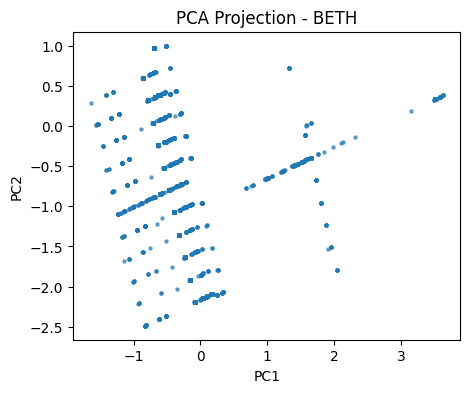


🔹 DBSCAN Clustering
eps=0.3, min_samples=3, clusters=4, silhouette=0.526
eps=0.3, min_samples=5, clusters=4, silhouette=0.526
eps=0.3, min_samples=10, clusters=3, silhouette=0.566
eps=0.5, min_samples=3, clusters=4, silhouette=0.526
eps=0.5, min_samples=5, clusters=4, silhouette=0.526
eps=0.5, min_samples=10, clusters=3, silhouette=0.526
eps=0.7, min_samples=3, clusters=3, silhouette=0.550
eps=0.7, min_samples=5, clusters=3, silhouette=0.550
eps=0.7, min_samples=10, clusters=2, silhouette=0.550


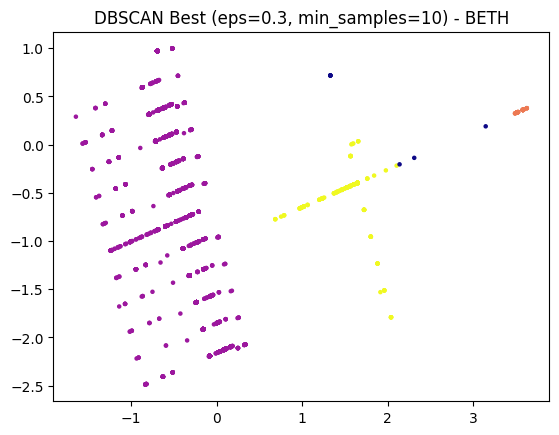

Best DBSCAN Silhouette: 0.566, Noise: 0.04%

🔹 Hierarchical Agglomerative Clustering (HAC)
Linkage=single, Silhouette=0.550


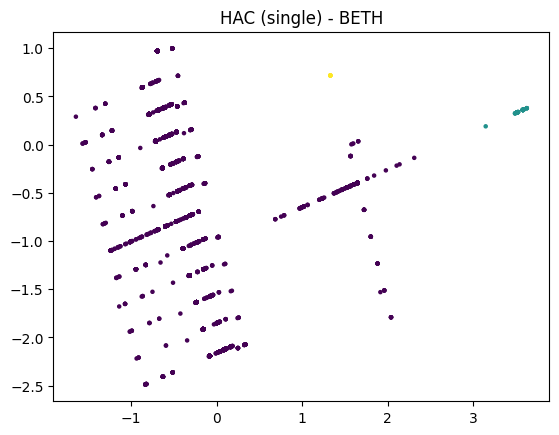

Linkage=complete, Silhouette=0.693


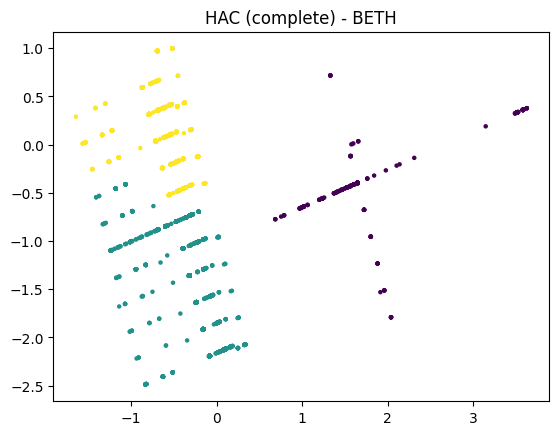

Linkage=average, Silhouette=0.575


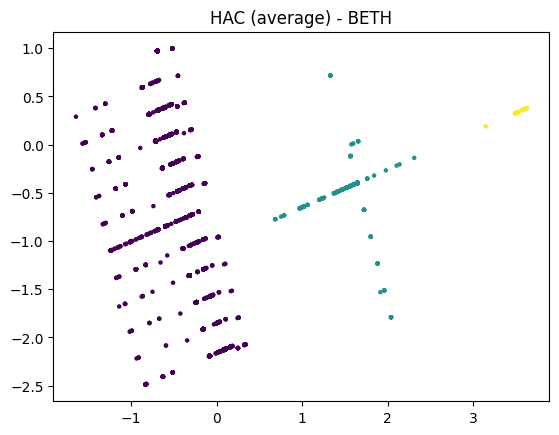

Linkage=ward, Silhouette=0.667


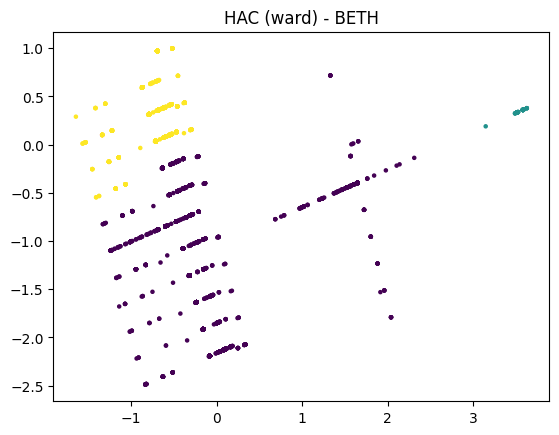

Best HAC linkage: complete (Silhouette=0.693)

🔹 Dendrogram (Ward)


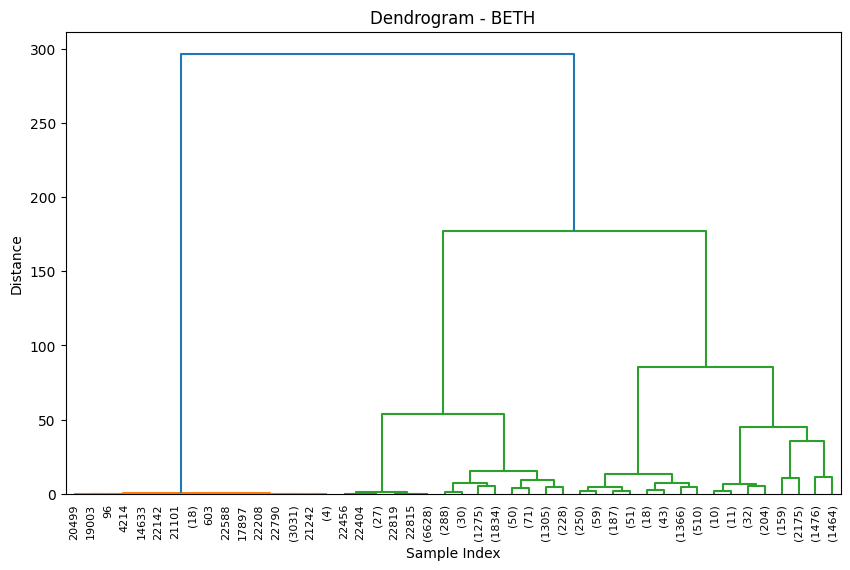

✅ Completed Clustering for BETH


==================== CSA DATASET ====================

Computing PCA to select top 3 features...
Top 3 PCA features extracted.
Sampled shape: (640, 3)


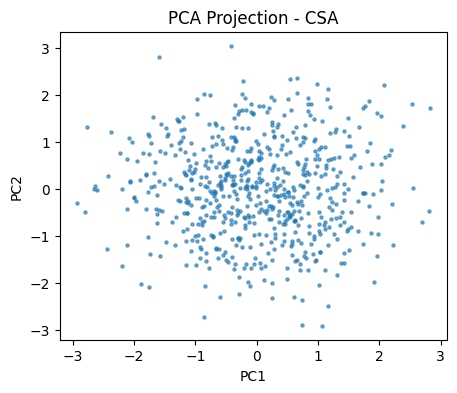


🔹 DBSCAN Clustering
eps=0.3, min_samples=3, clusters=4, silhouette=0.032
eps=0.3, min_samples=5, clusters=2, silhouette=0.221


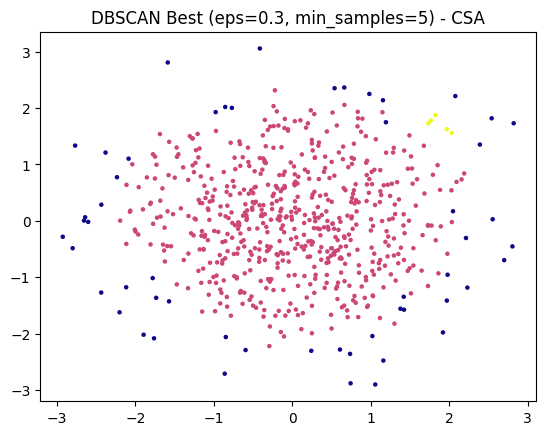

Best DBSCAN Silhouette: 0.221, Noise: 8.44%

🔹 Hierarchical Agglomerative Clustering (HAC)
Linkage=single, Silhouette=0.365


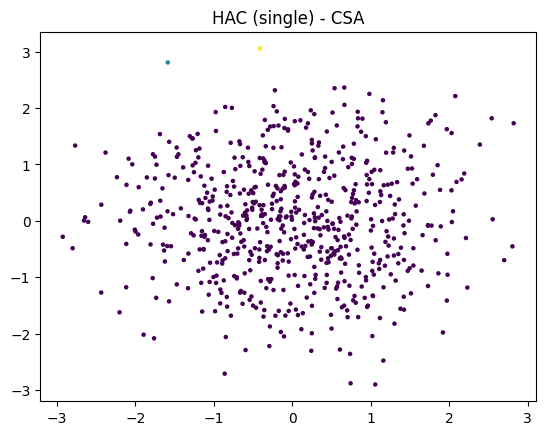

Linkage=complete, Silhouette=0.321


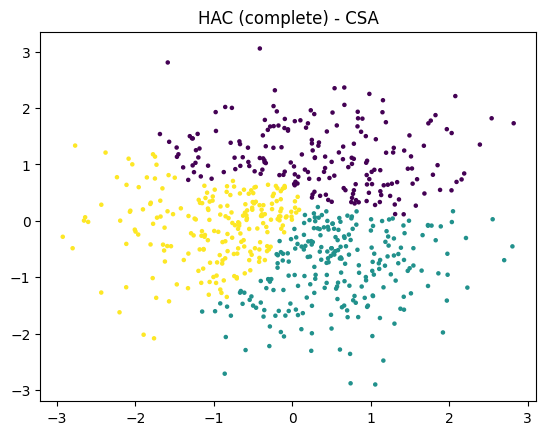

Linkage=average, Silhouette=0.229


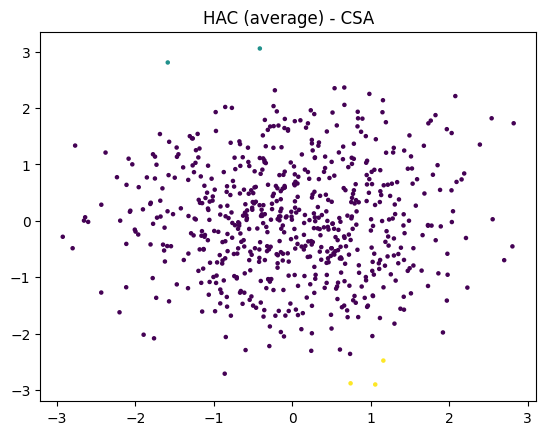

Linkage=ward, Silhouette=0.291


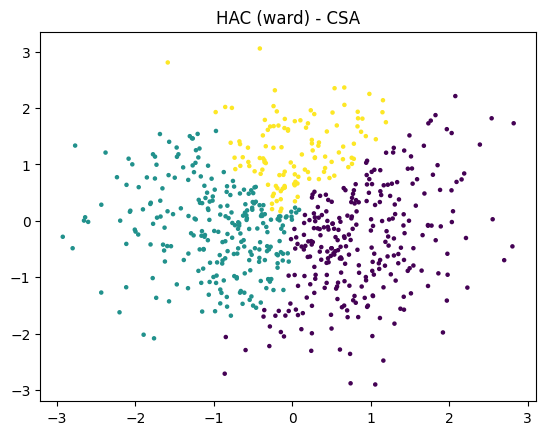

Best HAC linkage: single (Silhouette=0.365)

🔹 Dendrogram (Ward)


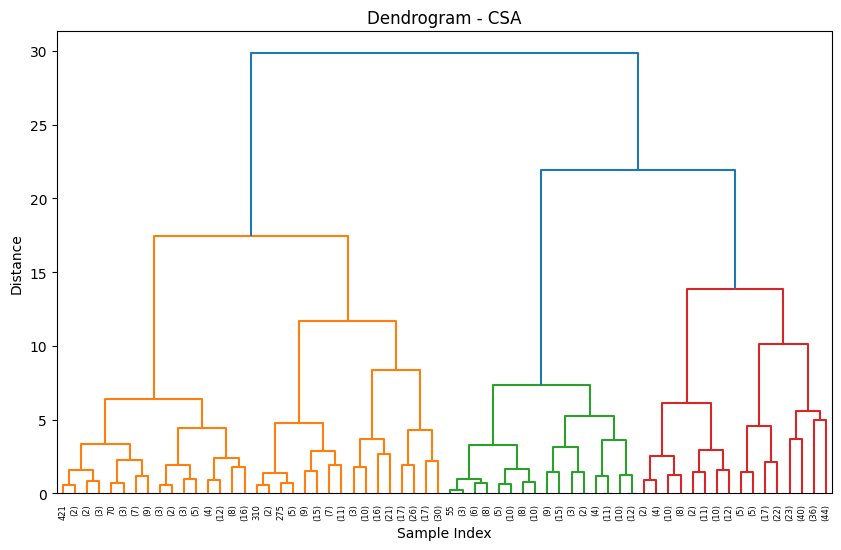

✅ Completed Clustering for CSA


==================== UNSW_NB15 DATASET ====================

Computing PCA to select top 3 features...
Top 3 PCA features extracted.
Sampled shape: (4122, 3)


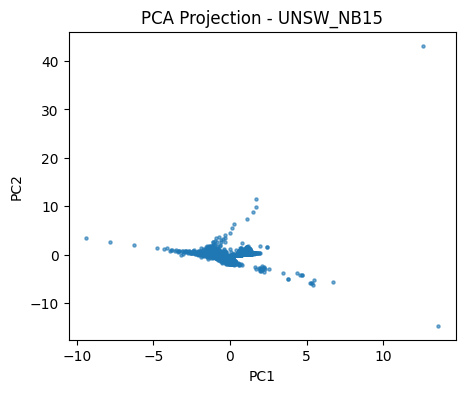


🔹 DBSCAN Clustering
eps=0.3, min_samples=3, clusters=6, silhouette=0.531
eps=0.3, min_samples=5, clusters=3, silhouette=0.529
eps=0.3, min_samples=10, clusters=2, silhouette=0.626
eps=0.5, min_samples=3, clusters=5, silhouette=0.512
eps=0.5, min_samples=5, clusters=2, silhouette=0.641
eps=0.5, min_samples=10, clusters=2, silhouette=0.641
eps=0.7, min_samples=3, clusters=5, silhouette=0.512
eps=0.7, min_samples=5, clusters=3, silhouette=0.643
eps=0.7, min_samples=10, clusters=2, silhouette=0.642
eps=1.0, min_samples=3, clusters=3, silhouette=0.775
eps=1.0, min_samples=5, clusters=3, silhouette=0.775


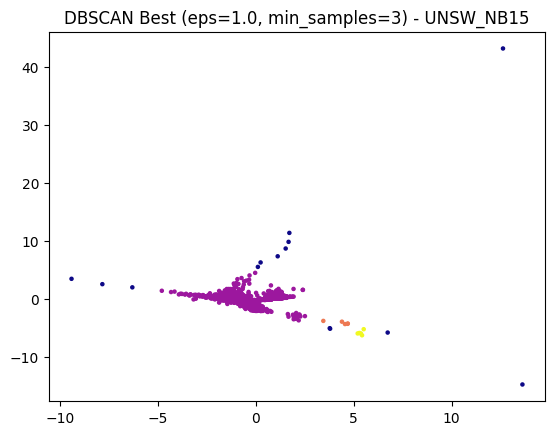

Best DBSCAN Silhouette: 0.775, Noise: 0.34%

🔹 Hierarchical Agglomerative Clustering (HAC)
Linkage=single, Silhouette=0.930


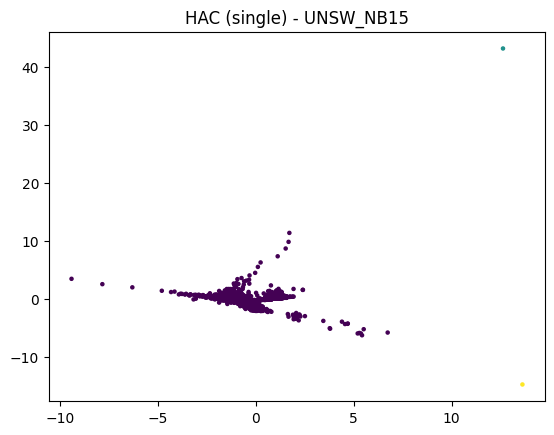

Linkage=complete, Silhouette=0.757


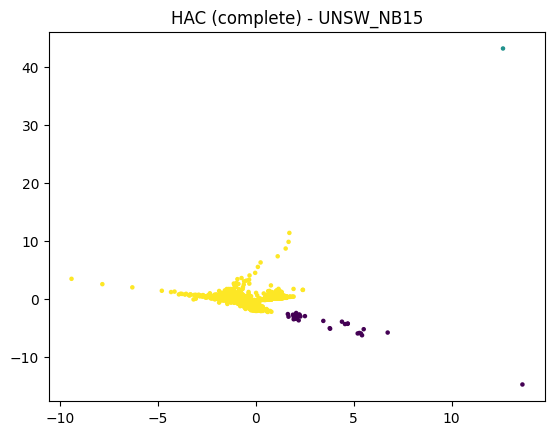

Linkage=average, Silhouette=0.930


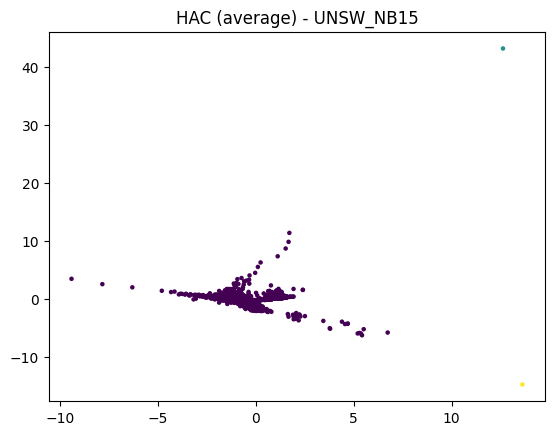

Linkage=ward, Silhouette=0.535


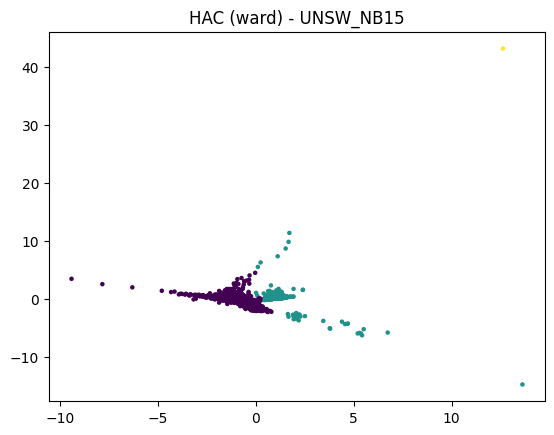

Best HAC linkage: single (Silhouette=0.930)

🔹 Dendrogram (Ward)


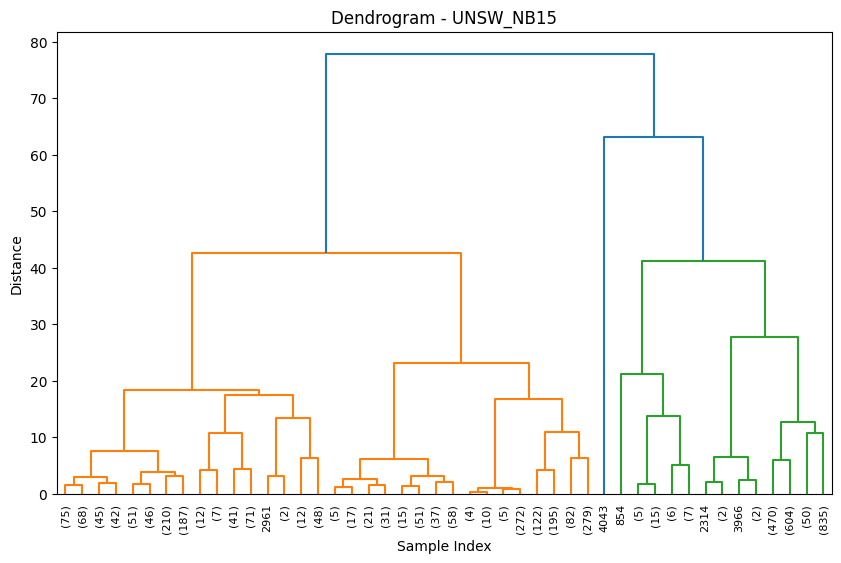

✅ Completed Clustering for UNSW_NB15



In [ ]:
# ==========================================================
# Week 11: DBSCAN + HAC (Targeted Features + PCA)
# ==========================================================
 
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
 

# -----------------------------------------------------------
# Helper function: Adaptive Sampling
# -----------------------------------------------------------
def adaptive_sample(df, frac=0.02, min_rows=200):
    n_rows = max(min_rows, int(len(df) * frac))
    return df.sample(n=n_rows, random_state=42)

# -----------------------------------------------------------
# Core function: Clustering Analysis
# -----------------------------------------------------------
def clustering_analysis(dataset_name, df, key_features=None):
    print(f"\n{'='*20} {dataset_name} DATASET {'='*20}\n")

    # --- 1️⃣ Feature Selection ---
    if key_features is not None:
        X = df[key_features]
        print(f"Using domain features: {key_features}")
    else:
        print("Computing PCA to select top 3 features...")
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df)
        pca = PCA(n_components=3)
        X_pca = pca.fit_transform(X_scaled)
        X = pd.DataFrame(X_pca, columns=[f"PCA_{i+1}" for i in range(3)])
        print("Top 3 PCA features extracted.")

    # --- 2️⃣ Adaptive Sampling ---
    X_sampled = adaptive_sample(X)
    print(f"Sampled shape: {X_sampled.shape}")

    # --- 3️⃣ Standardize ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sampled)

    # --- 4️⃣ PCA for Visualization ---
    pca_vis = PCA(n_components=2)
    X_pca_vis = pca_vis.fit_transform(X_scaled)

    plt.figure(figsize=(5,4))
    plt.scatter(X_pca_vis[:,0], X_pca_vis[:,1], s=5, alpha=0.6)
    plt.title(f"PCA Projection - {dataset_name}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    # --- 5️⃣ DBSCAN ---
    print("\n🔹 DBSCAN Clustering")
    eps_values = [0.3, 0.5, 0.7, 1.0]
    min_samples_values = [3, 5, 10]
    best_score = -1
    best_labels = None
    best_params = None

    for eps in eps_values:
        for min_samples in min_samples_values:
            db = DBSCAN(eps=eps, min_samples=min_samples)
            labels = db.fit_predict(X_pca_vis)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters > 1:
                score = silhouette_score(X_pca_vis, labels)
                if score > best_score:
                    best_score = score
                    best_labels = labels
                    best_params = (eps, min_samples)
                print(f"eps={eps}, min_samples={min_samples}, clusters={n_clusters}, silhouette={score:.3f}")

    if best_labels is not None:
        plt.scatter(X_pca_vis[:,0], X_pca_vis[:,1], c=best_labels, cmap='plasma', s=5)
        plt.title(f"DBSCAN Best (eps={best_params[0]}, min_samples={best_params[1]}) - {dataset_name}")
        plt.show()
        noise_ratio = list(best_labels).count(-1) / len(best_labels)
        print(f"Best DBSCAN Silhouette: {best_score:.3f}, Noise: {noise_ratio*100:.2f}%")
    else:
        print("No valid DBSCAN clusters found.")

    # --- 6️⃣ Hierarchical Clustering ---
    print("\n🔹 Hierarchical Agglomerative Clustering (HAC)")
    linkages = ['single', 'complete', 'average', 'ward']
    hac_scores = {}

    for method in linkages:
        hac = AgglomerativeClustering(n_clusters=3, linkage=method)
        labels = hac.fit_predict(X_pca_vis)
        score = silhouette_score(X_pca_vis, labels)
        hac_scores[method] = score
        print(f"Linkage={method}, Silhouette={score:.3f}")
        plt.scatter(X_pca_vis[:,0], X_pca_vis[:,1], c=labels, cmap='viridis', s=5)
        plt.title(f"HAC ({method}) - {dataset_name}")
        plt.show()

    best_linkage = max(hac_scores, key=hac_scores.get)
    print(f"Best HAC linkage: {best_linkage} (Silhouette={hac_scores[best_linkage]:.3f})")

    # --- 7️⃣ Dendrogram ---
    print("\n🔹 Dendrogram (Ward)")
    linked = linkage(X_pca_vis, method='ward')
    plt.figure(figsize=(10,6))
    dendrogram(linked, truncate_mode='level', p=5)
    plt.title(f"Dendrogram - {dataset_name}")
    plt.xlabel("Sample Index")
    plt.ylabel("Distance")
    plt.show()

    print(f"✅ Completed Clustering for {dataset_name}\n")

# -----------------------------------------------------------   
# Run Analysis
# -----------------------------------------------------------

# BETH → domain features only
clustering_analysis("BETH", df_beth_merged, key_features=['processName','userId','hostName'])

# CSA & UNSW → top 3 PCA features only
clustering_analysis("CSA", X_train_csa_reg_df)
clustering_analysis("UNSW_NB15", X_train_unsw_reg_df)


# Conclusion
Clustering analysis was performed on three datasets—BETH, CSA, and UNSW_NB15—using DBSCAN and Hierarchical Agglomerative Clustering (HAC), along with PCA for dimensionality reduction and visualization.

For BETH, we focused on domain-specific features (processName, userId, hostName) and applied adaptive sampling (~22,800 rows, 5% of total) due to computational constraints. DBSCAN produced 2–4 clusters depending on eps and min_samples, with the best silhouette score of 0.566 at eps=0.3 and min_samples=10 and only 0.04% noise, effectively capturing anomalous process-user-host interactions. HAC performed better, with silhouette scores across linkages: single=0.550, complete=0.693, average=0.575, ward=0.667, and complete linkage selected as best, indicating clearer hierarchical separation. PCA revealed that processName dominated PC1 and hostName dominated PC2, which were used for clustering visualization.

For CSA, the dataset was smaller, and we used the top 3 PCA components for clustering. Adaptive sampling reduced the dataset to 640 rows for efficiency. DBSCAN struggled to identify distinct clusters, generating 2–4 clusters with a maximum silhouette of 0.221 (eps=0.3, min_samples=5), highlighting the limited variation captured by the top PCA components. HAC achieved slightly better results, with silhouette scores: single=0.365, complete=0.321, average=0.229, ward=0.291, with single linkage selected as best, suggesting that the structure is weakly clustered and additional features may be required. Top PCA components were mainly influenced by traffic rate and packet statistics.

For UNSW_NB15, after adaptive sampling (~4,100 rows), the top 3 PCA components effectively captured key traffic and flow-based variations. DBSCAN identified 2–6 clusters with best silhouette 0.775 (eps=1.0, min_samples=3) and 0.34% noise, while HAC showed excellent hierarchical separation with silhouette scores: single=0.930, complete=0.757, average=0.930, ward=0.535, selecting single linkage as best. PCA analysis highlighted duration and sbytes as dominant contributors to PC1 and PC2, which strongly guided cluster formation.

Overall, adaptive sampling proved crucial for large datasets (BETH, UNSW_NB15) to reduce memory usage and computation time, while still maintaining representative patterns. DBSCAN is effective for detecting arbitrary-shaped clusters and outliers but is sensitive to parameter tuning and dataset homogeneity (e.g., CSA). HAC offers robust cluster separation and dendrogram interpretability, useful for hierarchical threat analysis. PCA significantly improved visualization and reduced dimensionality, and identifying top contributing components per dataset (BETH: processName, hostName; CSA: traffic and packet metrics; UNSW_NB15: duration, sbytes) was key for successful clustering. Future improvements may include incremental or mini-batch clustering for very large datasets and enhanced feature engineering for datasets like CSA to improve cluster quality.